In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report

FIGURE_DIR = "../outputs/figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

In [2]:
RGB_LOG = "../training_logs/training_logs_efficientnet.csv"
MS_LOG = "../training_logs/training_logs_multispectral.csv"

rgb_log = pd.read_csv(RGB_LOG)
ms_log = pd.read_csv(MS_LOG)

print("RGB Log")
display(rgb_log.head())

print("\nMultispectral Log")
display(ms_log.head())

RGB Log


,Model,Epoch,Train Loss,Train Accuracy (%),Val Loss,Val Accuracy (%)
0,rgb_efficientnetb0,1,0.582,80.7,0.308,90.0
1,rgb_efficientnetb0,2,0.326,88.8,0.222,93.1
2,rgb_efficientnetb0,3,0.276,90.6,0.188,93.9
3,rgb_efficientnetb0,4,0.249,91.5,0.198,93.2
4,rgb_efficientnetb0,5,0.236,92.1,0.177,94.1



Multispectral Log


,Model,Epoch,Train Loss,Train Accuracy (%),Val Loss,Val Accuracy (%)
0,MultispectralCNN,1,1.2429,72.17,1.4446,66.96
1,MultispectralCNN,2,0.9011,85.46,0.8776,86.22
2,MultispectralCNN,3,0.7698,90.65,0.7344,90.79
3,MultispectralCNN,4,0.7261,92.01,1.0626,81.73
4,MultispectralCNN,5,0.7061,92.81,0.8517,86.64


In [3]:
print("RGB Columns")
print(rgb_log.columns)

print("\nMS Columns")
print(ms_log.columns)

print("\nRGB Epochs :", len(rgb_log))
print("MS Epochs :", len(ms_log))

RGB Columns
Index(['Model', 'Epoch', 'Train Loss', 'Train Accuracy (%)', 'Val Loss',
       'Val Accuracy (%)'],
      dtype='str')

MS Columns
Index(['Model', 'Epoch', 'Train Loss', 'Train Accuracy (%)', 'Val Loss',
       'Val Accuracy (%)'],
      dtype='str')

RGB Epochs : 22
MS Epochs : 60


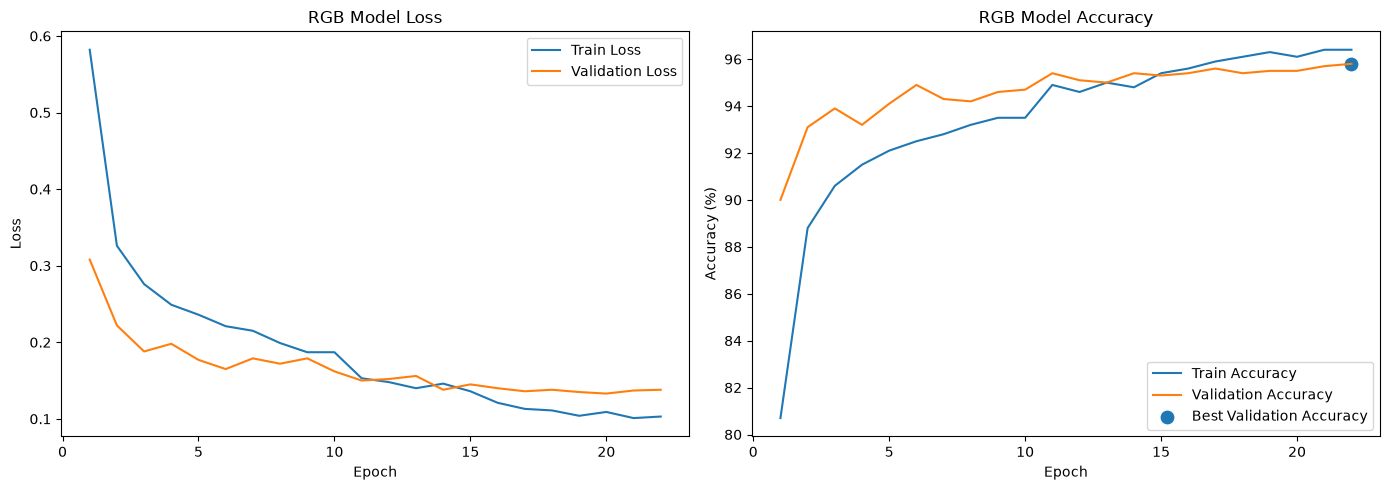

In [4]:
best_epoch = rgb_log["Val Accuracy (%)"].idxmax()

plt.figure(figsize=(14,5))

# ---------------- Loss ----------------
plt.subplot(1,2,1)

plt.plot(
    rgb_log["Epoch"],
    rgb_log["Train Loss"],
    label="Train Loss"
)

plt.plot(
    rgb_log["Epoch"],
    rgb_log["Val Loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RGB Model Loss")
plt.legend()

# ---------------- Accuracy ----------------

plt.subplot(1,2,2)

plt.plot(
    rgb_log["Epoch"],
    rgb_log["Train Accuracy (%)"],
    label="Train Accuracy"
)

plt.plot(
    rgb_log["Epoch"],
    rgb_log["Val Accuracy (%)"],
    label="Validation Accuracy"
)

plt.scatter(
    rgb_log.loc[best_epoch, "Epoch"],
    rgb_log.loc[best_epoch, "Val Accuracy (%)"],
    s=80,
    label="Best Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("RGB Model Accuracy")
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "rgb_training_curves.png"),
    dpi=300
)

plt.show()


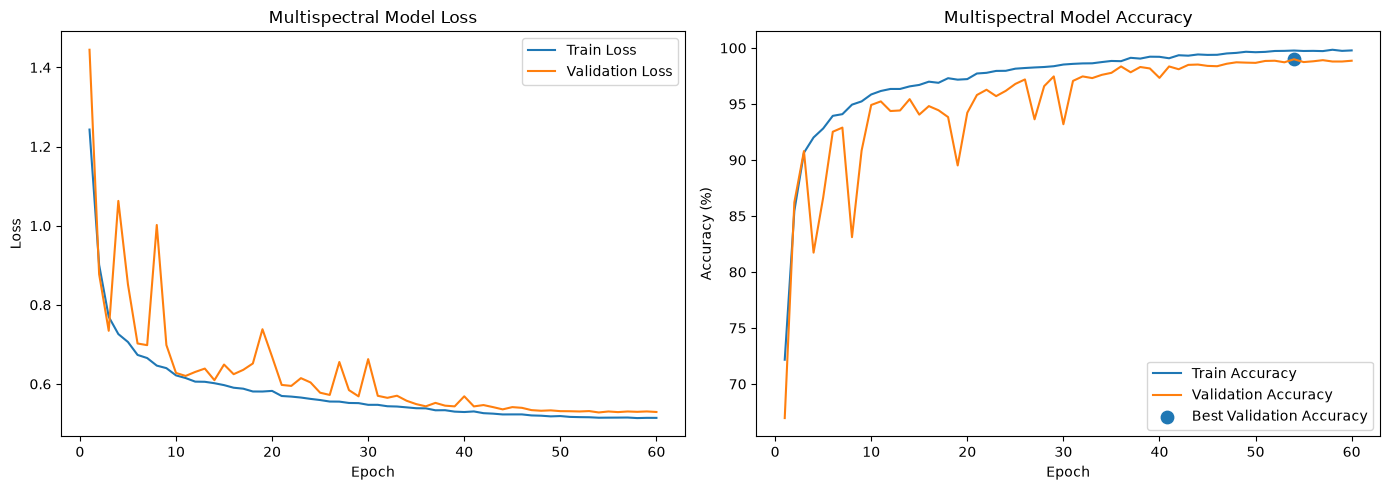

In [5]:
best_epoch = ms_log["Val Accuracy (%)"].idxmax()

plt.figure(figsize=(14,5))

# ---------------- Loss ----------------

plt.subplot(1,2,1)

plt.plot(
    ms_log["Epoch"],
    ms_log["Train Loss"],
    label="Train Loss"
)

plt.plot(
    ms_log["Epoch"],
    ms_log["Val Loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Multispectral Model Loss")
plt.legend()

# ---------------- Accuracy ----------------

plt.subplot(1,2,2)

plt.plot(
    ms_log["Epoch"],
    ms_log["Train Accuracy (%)"],
    label="Train Accuracy"
)

plt.plot(
    ms_log["Epoch"],
    ms_log["Val Accuracy (%)"],
    label="Validation Accuracy"
)

plt.scatter(
    ms_log.loc[best_epoch, "Epoch"],
    ms_log.loc[best_epoch, "Val Accuracy (%)"],
    s=80,
    label="Best Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Multispectral Model Accuracy")
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "ms_training_curves.png"),
    dpi=300
)

plt.show()

In [6]:
comparison = pd.DataFrame({

    "Metric":[
        "Best Validation Accuracy (%)",
        "Final Training Accuracy (%)",
        "Best Validation Loss",
        "Total Epochs"
    ],

    "RGB":[
        rgb_log["Val Accuracy (%)"].max(),
        rgb_log["Train Accuracy (%)"].iloc[-1],
        rgb_log["Val Loss"].min(),
        len(rgb_log)
    ],

    "Multispectral":[
        ms_log["Val Accuracy (%)"].max(),
        ms_log["Train Accuracy (%)"].iloc[-1],
        ms_log["Val Loss"].min(),
        len(ms_log)
    ]

})

comparison

,Metric,RGB,Multispectral
0,Best Validation Accuracy (%),95.800,98.990
1,Final Training Accuracy (%),96.400,99.780
2,Best Validation Loss,0.133,0.528
3,Total Epochs,22.000,60.000


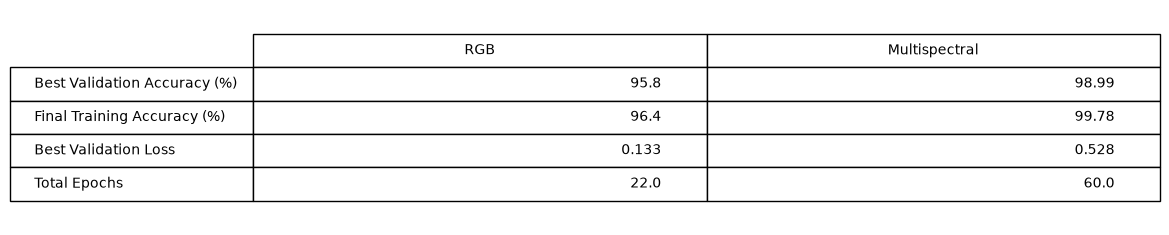

In [7]:
fig, ax = plt.subplots(figsize=(9,2.8))

ax.axis("off")

table = ax.table(
    cellText=np.round(comparison.iloc[:,1:].values,3),
    rowLabels=comparison["Metric"],
    colLabels=["RGB","Multispectral"],
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.3,2)

plt.savefig(
    os.path.join(FIGURE_DIR,"model_comparison.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

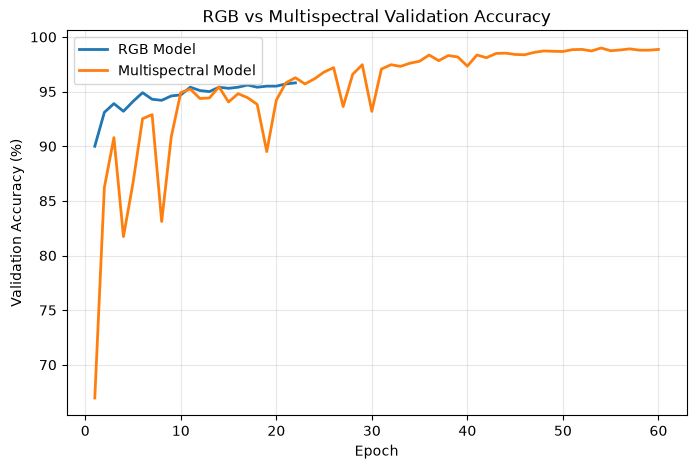

In [8]:
plt.figure(figsize=(8,5))

plt.plot(
    rgb_log["Epoch"],
    rgb_log["Val Accuracy (%)"],
    linewidth=2,
    label="RGB Model"
)

plt.plot(
    ms_log["Epoch"],
    ms_log["Val Accuracy (%)"],
    linewidth=2,
    label="Multispectral Model"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")

plt.title("RGB vs Multispectral Validation Accuracy")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [9]:
RGB_PRED = "../outputs/predictions/rgb_val_predictions.csv"
MS_PRED = "../outputs/predictions/ms_val_predictions.csv"

rgb_pred = pd.read_csv(RGB_PRED)
ms_pred = pd.read_csv(MS_PRED)

print("RGB Prediction File")
display(rgb_pred.head())

print("\nMS Prediction File")
display(ms_pred.head())

RGB Prediction File


,filename,classname,true_label,predicted_label
0,../EuroSAT_Dataset/EuroSAT\val\AnnualCrop\Annu...,AnnualCrop,0,0
1,../EuroSAT_Dataset/EuroSAT\val\AnnualCrop\Annu...,AnnualCrop,0,0
2,../EuroSAT_Dataset/EuroSAT\val\AnnualCrop\Annu...,AnnualCrop,0,0
3,../EuroSAT_Dataset/EuroSAT\val\AnnualCrop\Annu...,AnnualCrop,0,0
4,../EuroSAT_Dataset/EuroSAT\val\AnnualCrop\Annu...,AnnualCrop,0,0



MS Prediction File


,filename,classname,true_label,predicted_label
0,../EuroSAT_Dataset/EuroSATallBands\val\AnnualC...,AnnualCrop,0,0
1,../EuroSAT_Dataset/EuroSATallBands\val\AnnualC...,AnnualCrop,0,0
2,../EuroSAT_Dataset/EuroSATallBands\val\AnnualC...,AnnualCrop,0,0
3,../EuroSAT_Dataset/EuroSATallBands\val\AnnualC...,AnnualCrop,0,0
4,../EuroSAT_Dataset/EuroSATallBands\val\AnnualC...,AnnualCrop,0,0


In [12]:
print("="*60)
print("RGB MODEL CLASSIFICATION REPORT")
print("="*60)

print(
    classification_report(
        rgb_pred["true_label"],
        rgb_pred["predicted_label"],
        target_names=sorted(rgb_pred["classname"].unique())
    )
)

RGB MODEL CLASSIFICATION REPORT
                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.98      0.96       450
              Forest       0.97      0.97      0.97       450
HerbaceousVegetation       0.93      0.96      0.95       450
             Highway       0.96      0.92      0.94       375
          Industrial       0.98      0.98      0.98       375
             Pasture       0.95      0.93      0.94       300
       PermanentCrop       0.96      0.92      0.94       375
         Residential       0.98      0.99      0.99       450
               River       0.96      0.98      0.97       375
             SeaLake       0.99      0.99      0.99       450

            accuracy                           0.96      4050
           macro avg       0.96      0.96      0.96      4050
        weighted avg       0.96      0.96      0.96      4050



In [13]:
print("="*60)
print("MULTISPECTRAL MODEL CLASSIFICATION REPORT")
print("="*60)

print(
    classification_report(
        ms_pred["true_label"],
        ms_pred["predicted_label"],
        target_names=sorted(ms_pred["classname"].unique())
    )
)

MULTISPECTRAL MODEL CLASSIFICATION REPORT
                      precision    recall  f1-score   support

          AnnualCrop       0.99      0.99      0.99       450
              Forest       0.99      1.00      0.99       450
HerbaceousVegetation       0.99      0.98      0.99       450
             Highway       0.99      0.99      0.99       375
          Industrial       0.98      0.99      0.99       375
             Pasture       0.97      0.99      0.98       300
       PermanentCrop       0.99      0.98      0.99       375
         Residential       0.99      0.99      0.99       450
               River       0.99      0.99      0.99       375
             SeaLake       1.00      1.00      1.00       450

            accuracy                           0.99      4050
           macro avg       0.99      0.99      0.99      4050
        weighted avg       0.99      0.99      0.99      4050

